# Exercise 8 — Logistic Regression from Scratch
### Sigmoid · Log-Loss · Gradient Descent · Decision Boundary

**Goal:** Implement the full logistic regression training loop in pure NumPy — no sklearn for the model — and visualise every step.

| Component | What we build |
|-----------|---------------|
| `sigmoid(z)` | Maps any real number to (0, 1) |
| `log_loss(y, ŷ)` | Binary cross-entropy loss |
| Gradient descent | Iterative weight update using dL/dw and dL/db |
| Decision boundary | Contour line where P(y=1) = 0.5 |
| L2 regularisation | Bonus: adds weight penalty to constrain the boundary |

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets        import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

plt.rcParams.update({
    'figure.dpi'        : 130,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 11,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
})

SEED   = 42
C0     = '#4C72B0'
C1     = '#DD8452'
C_LOSS = '#C44E52'
C_L2   = '#55A868'

print('Setup complete.')

Setup complete.


## 1 · Task 1 — Generate 2D Binary Dataset

Total samples : 500
Features      : 2  (x1, x2)
Classes       : [0 1]  |  balance: 250 / 250
Train / Test  : 400 / 100


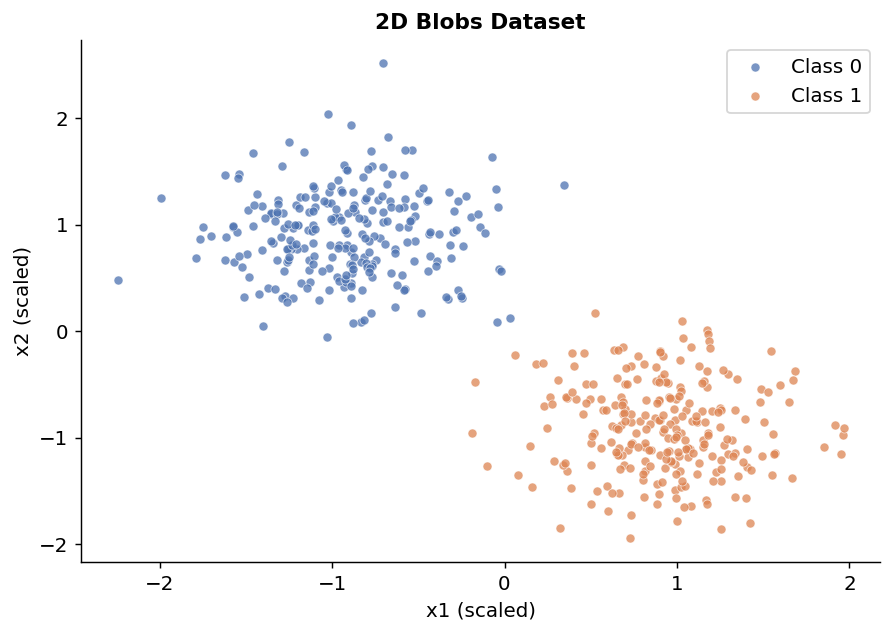

In [2]:
X_raw, y = make_blobs(
    n_samples    = 500,
    centers      = 2,
    n_features   = 2,
    cluster_std  = 1.6,
    random_state = SEED,
)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'Total samples : {len(X)}')
print(f'Features      : {X.shape[1]}  (x1, x2)')
print(f'Classes       : {np.unique(y)}  |  balance: {(y==0).sum()} / {(y==1).sum()}')
print(f'Train / Test  : {len(X_train)} / {len(X_test)}')

fig, ax = plt.subplots(figsize=(7, 5))
for cls, col, lbl in [(0, C0, 'Class 0'), (1, C1, 'Class 1')]:
    mask = y == cls
    ax.scatter(X[mask, 0], X[mask, 1], c=col, s=25, alpha=0.75,
               edgecolors='white', linewidths=0.4, label=lbl)
ax.set_xlabel('x1 (scaled)')
ax.set_ylabel('x2 (scaled)')
ax.set_title('2D Blobs Dataset')
ax.legend()
plt.tight_layout()
plt.show()

## 2 · The Maths

**Forward pass**
```
z = X @ w + b
y_hat = sigmoid(z) = 1 / (1 + exp(-z))
```

**Binary cross-entropy (log-loss)**
```
L = -(1/N) * sum( y * log(y_hat) + (1-y) * log(1-y_hat) )
```

**Gradients** (closed-form for logistic regression)
```
dL/dw = (1/N) * X.T @ (y_hat - y)         + lambda * w  (with L2)
dL/db = (1/N) * sum(y_hat - y)
```

**Update rule**
```
w = w - lr * dL/dw
b = b - lr * dL/db
```

> **Note:** The bias `b` is NOT regularised — this is standard practice.

## 2 · Task 2 — Implement sigmoid, log-loss, gradients

In [3]:
def sigmoid(z):
    """sigma(z) = 1 / (1 + exp(-z)).  Clipped for numerical stability."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def log_loss(y_true, y_pred):
    """Binary cross-entropy.  y_pred clipped away from 0/1 to avoid log(0)."""
    eps    = 1e-15
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred))


def compute_gradients(X, y_true, y_pred, w, lam=0.0):
    """Return (dw, db) for log-loss + optional L2 penalty lambda on w."""
    n   = len(y_true)
    err = y_pred - y_true
    dw  = (X.T @ err) / n + lam * w
    db  = err.mean()
    return dw, db


def train_logistic(X_tr, y_tr, lr=0.1, n_epochs=300, lam=0.0, X_val=None, y_val=None):
    """
    Batch gradient descent for logistic regression.
    Returns: w, b, history dict with 'train_loss' and 'val_loss'.
    """
    w       = np.zeros(X_tr.shape[1])
    b       = 0.0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(n_epochs):
        z      = X_tr @ w + b
        y_hat  = sigmoid(z)
        loss   = log_loss(y_tr, y_hat) + (lam / 2.0) * np.dot(w, w)
        dw, db = compute_gradients(X_tr, y_tr, y_hat, w, lam)
        w     -= lr * dw
        b     -= lr * db
        history['train_loss'].append(loss)
        if X_val is not None:
            v_hat = sigmoid(X_val @ w + b)
            history['val_loss'].append(
                log_loss(y_val, v_hat) + (lam / 2.0) * np.dot(w, w)
            )

    return w, b, history


def predict(X, w, b, threshold=0.5):
    return (sigmoid(X @ w + b) >= threshold).astype(int)


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


# Unit tests
assert abs(sigmoid(0) - 0.5) < 1e-10
assert abs(sigmoid(100) - 1.0) < 1e-6
assert abs(sigmoid(-100)) < 1e-6
assert log_loss(np.array([1.0]), np.array([1.0 - 1e-15])) < 1e-10
print('All functions defined and unit tests passed.')

All functions defined and unit tests passed.


## 3 · Sigmoid & Log-Loss Visualisation

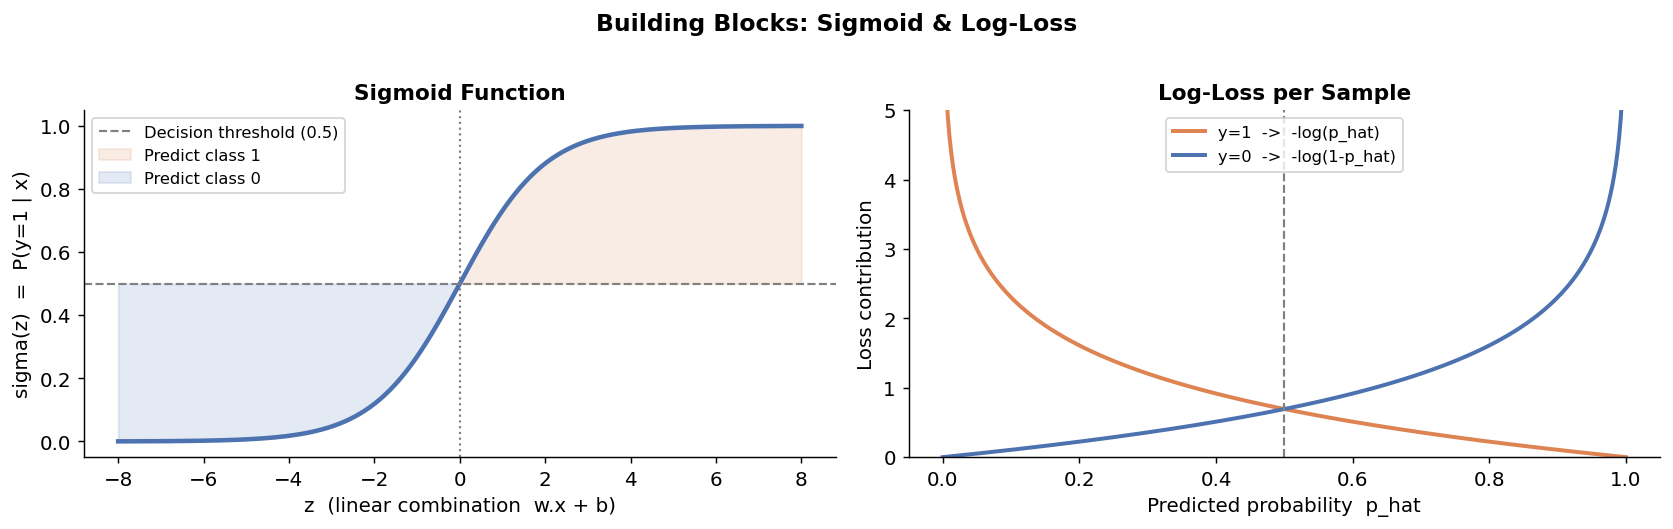

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

z_range = np.linspace(-8, 8, 400)
sig     = sigmoid(z_range)

ax = axes[0]
ax.plot(z_range, sig, color=C0, lw=2.5)
ax.axhline(0.5, color='grey', ls='--', lw=1.2, label='Decision threshold (0.5)')
ax.axvline(0.0, color='grey', ls=':',  lw=1.2)
ax.fill_between(z_range, sig, 0.5, where=(sig > 0.5), alpha=0.15, color=C1,
                label='Predict class 1')
ax.fill_between(z_range, sig, 0.5, where=(sig < 0.5), alpha=0.15, color=C0,
                label='Predict class 0')
ax.set_xlabel('z  (linear combination  w.x + b)')
ax.set_ylabel('sigma(z)  =  P(y=1 | x)')
ax.set_title('Sigmoid Function')
ax.legend(fontsize=9)

p_range  = np.linspace(1e-6, 1 - 1e-6, 400)
ax2 = axes[1]
ax2.plot(p_range, -np.log(p_range),       color=C1, lw=2.2, label='y=1  ->  -log(p_hat)')
ax2.plot(p_range, -np.log(1 - p_range),   color=C0, lw=2.2, label='y=0  ->  -log(1-p_hat)')
ax2.axvline(0.5, color='grey', ls='--',   lw=1.2)
ax2.set_ylim(0, 5)
ax2.set_xlabel('Predicted probability  p_hat')
ax2.set_ylabel('Loss contribution')
ax2.set_title('Log-Loss per Sample')
ax2.legend(fontsize=9)

plt.suptitle('Building Blocks: Sigmoid & Log-Loss',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4 · Task 3 — Train with Gradient Descent

In [5]:
LEARNING_RATE = 0.5
N_EPOCHS      = 300

w, b, history = train_logistic(
    X_train, y_train,
    lr       = LEARNING_RATE,
    n_epochs = N_EPOCHS,
    X_val    = X_test,
    y_val    = y_test,
)

print(f'Final weights : w = {w.round(4)}')
print(f'Final bias    : b = {b:.4f}')
print(f'Train loss    : {history["train_loss"][-1]:.4f}')
print(f'Val   loss    : {history["val_loss"][-1]:.4f}')
print(f'Train accuracy: {accuracy(y_train, predict(X_train, w, b)):.4f}')
print(f'Test  accuracy: {accuracy(y_test,  predict(X_test,  w, b)):.4f}')

Final weights : w = [ 3.3248 -3.3814]
Final bias    : b = -0.0077
Train loss    : 0.0153
Val   loss    : 0.0062
Train accuracy: 1.0000
Test  accuracy: 1.0000


## 5 · Task 4 — Loss vs Epoch

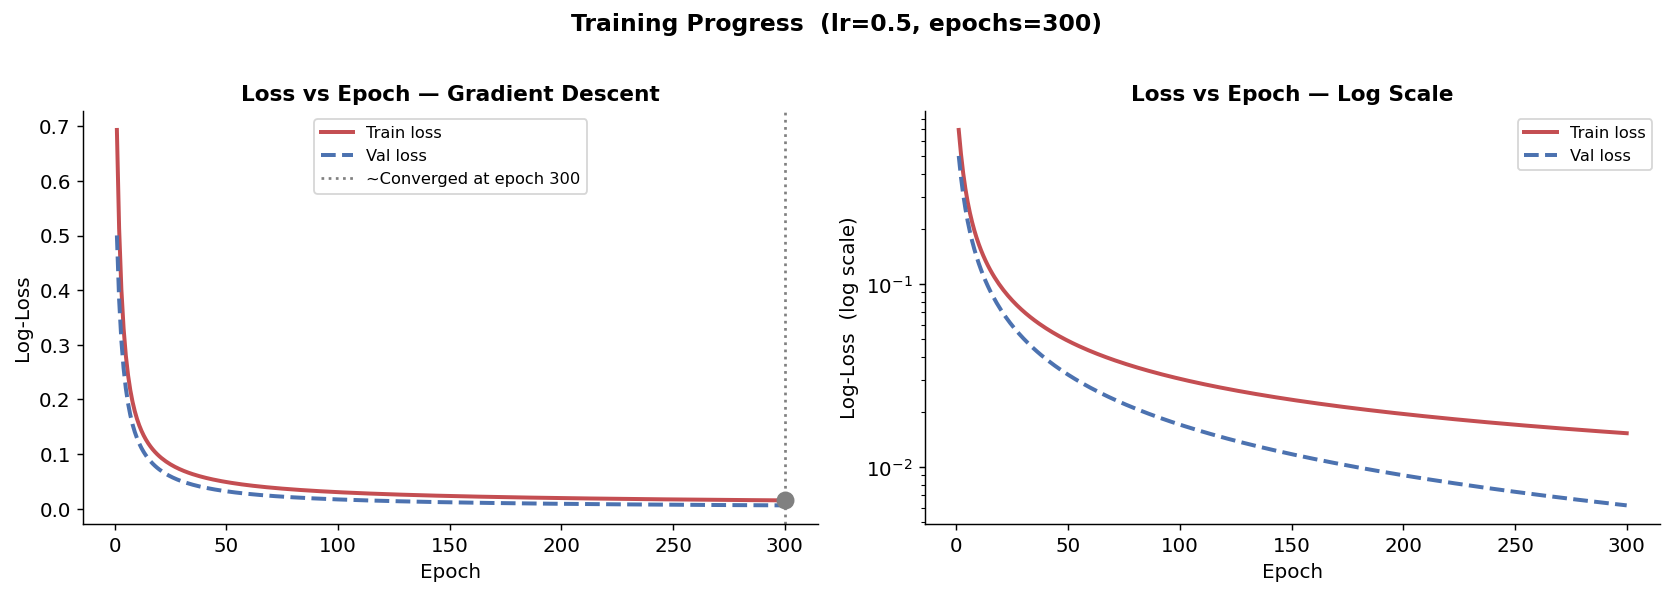


Loss table (sampled):
 epoch  train_loss  val_loss
     1     0.69315   0.50014
    31     0.06912   0.04890
    61     0.04247   0.02670
    91     0.03231   0.01859
   121     0.02677   0.01433
   151     0.02323   0.01170
   181     0.02074   0.00990
   211     0.01888   0.00859
   241     0.01742   0.00759
   271     0.01625   0.00680
   300     0.01531   0.00618


In [6]:
epochs = np.arange(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(epochs, history['train_loss'], color=C_LOSS, lw=2.2, label='Train loss')
ax.plot(epochs, history['val_loss'],   color=C0,     lw=2.2, ls='--', label='Val loss')

diffs = np.abs(np.diff(history['train_loss']))
conv_epoch = int(np.argmax(diffs < 1e-5)) + 1 if np.any(diffs < 1e-5) else N_EPOCHS
ax.axvline(conv_epoch, color='grey', ls=':', lw=1.5, label=f'~Converged at epoch {conv_epoch}')
ax.scatter([conv_epoch], [history['train_loss'][conv_epoch-1]], s=80, color='grey', zorder=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log-Loss')
ax.set_title('Loss vs Epoch — Gradient Descent')
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.semilogy(epochs, history['train_loss'], color=C_LOSS, lw=2.2, label='Train loss')
ax2.semilogy(epochs, history['val_loss'],   color=C0,     lw=2.2, ls='--', label='Val loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Log-Loss  (log scale)')
ax2.set_title('Loss vs Epoch — Log Scale')
ax2.legend(fontsize=9)

plt.suptitle(f'Training Progress  (lr={LEARNING_RATE}, epochs={N_EPOCHS})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Sample loss table
sample_epochs = list(range(0, N_EPOCHS, 30)) + [N_EPOCHS - 1]
loss_table = pd.DataFrame({
    'epoch'     : [e + 1 for e in sample_epochs],
    'train_loss': [round(history['train_loss'][e], 5) for e in sample_epochs],
    'val_loss'  : [round(history['val_loss'][e],   5) for e in sample_epochs],
})
print('\nLoss table (sampled):')
print(loss_table.to_string(index=False))

## 6 · Task 5 — Decision Boundary in 2D

In [7]:
def plot_decision_boundary(ax, X_data, y_data, w, b, title='', resolution=400):
    """
    Probability heatmap + decision boundary contour + data scatter.
    Boundary: the P=0.5 contour (solid black line).
    Dashed lines at P=0.25 and P=0.75 show confidence regions.
    """
    pad  = 0.4
    x1lo, x1hi = X_data[:, 0].min() - pad, X_data[:, 0].max() + pad
    x2lo, x2hi = X_data[:, 1].min() - pad, X_data[:, 1].max() + pad
    xx1, xx2   = np.meshgrid(
        np.linspace(x1lo, x1hi, resolution),
        np.linspace(x2lo, x2hi, resolution),
    )
    grid  = np.c_[xx1.ravel(), xx2.ravel()]
    proba = sigmoid(grid @ w + b).reshape(xx1.shape)

    im = ax.contourf(xx1, xx2, proba, levels=50, cmap='RdYlBu_r', alpha=0.55)
    plt.colorbar(im, ax=ax, label='P(y=1)', fraction=0.035, pad=0.02)

    ax.contour(xx1, xx2, proba, levels=[0.5],         colors='black', linewidths=2.5)
    ax.contour(xx1, xx2, proba, levels=[0.25, 0.75],  colors='black',
               linewidths=1.0, linestyles='--', alpha=0.5)

    for cls, col in [(0, C0), (1, C1)]:
        mask = y_data == cls
        ax.scatter(X_data[mask, 0], X_data[mask, 1],
                   c=col, s=28, edgecolors='white', linewidths=0.5,
                   alpha=0.85, zorder=3, label=f'Class {cls}')

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend(fontsize=9, loc='upper left')


print('plot_decision_boundary() defined.')

plot_decision_boundary() defined.


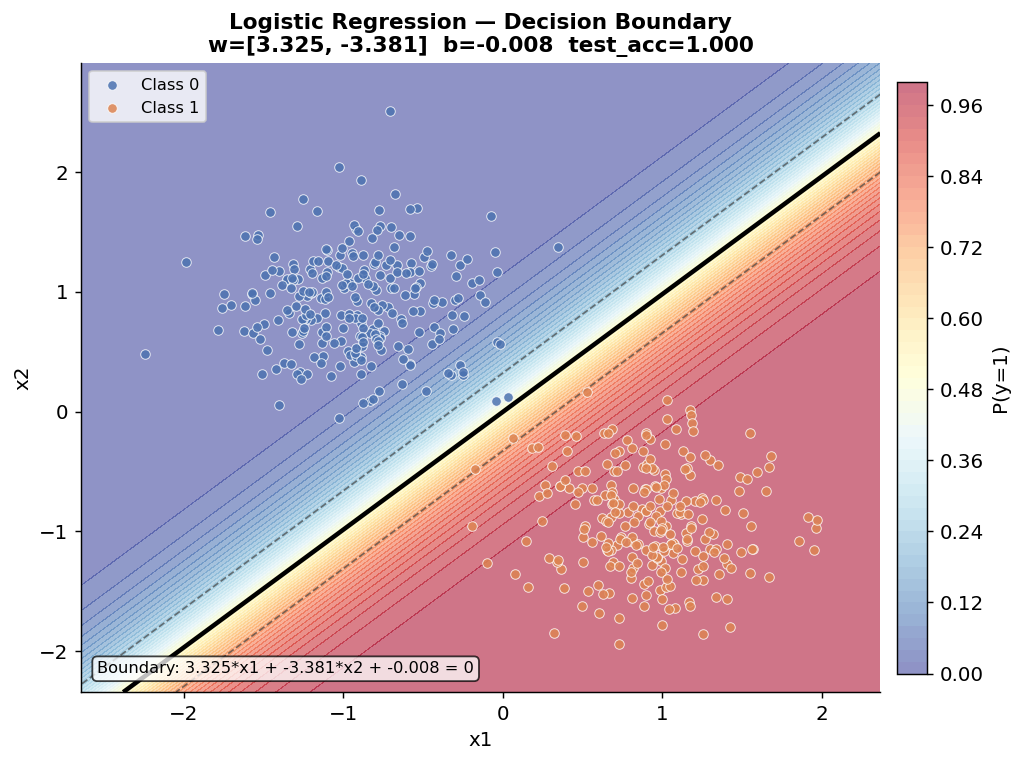

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

test_acc = accuracy(y_test, predict(X_test, w, b))
plot_decision_boundary(
    ax, X, y, w, b,
    title=(
        f'Logistic Regression — Decision Boundary\n'
        f'w=[{w[0]:.3f}, {w[1]:.3f}]  b={b:.3f}  test_acc={test_acc:.3f}'
    ),
)

ax.annotate(
    f'Boundary: {w[0]:.3f}*x1 + {w[1]:.3f}*x2 + {b:.3f} = 0',
    xy=(0.02, 0.03), xycoords='axes fraction',
    fontsize=9, color='black',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.75),
)
plt.tight_layout()
plt.show()

## 7 · Gradient Descent — Snapshots at Different Epochs

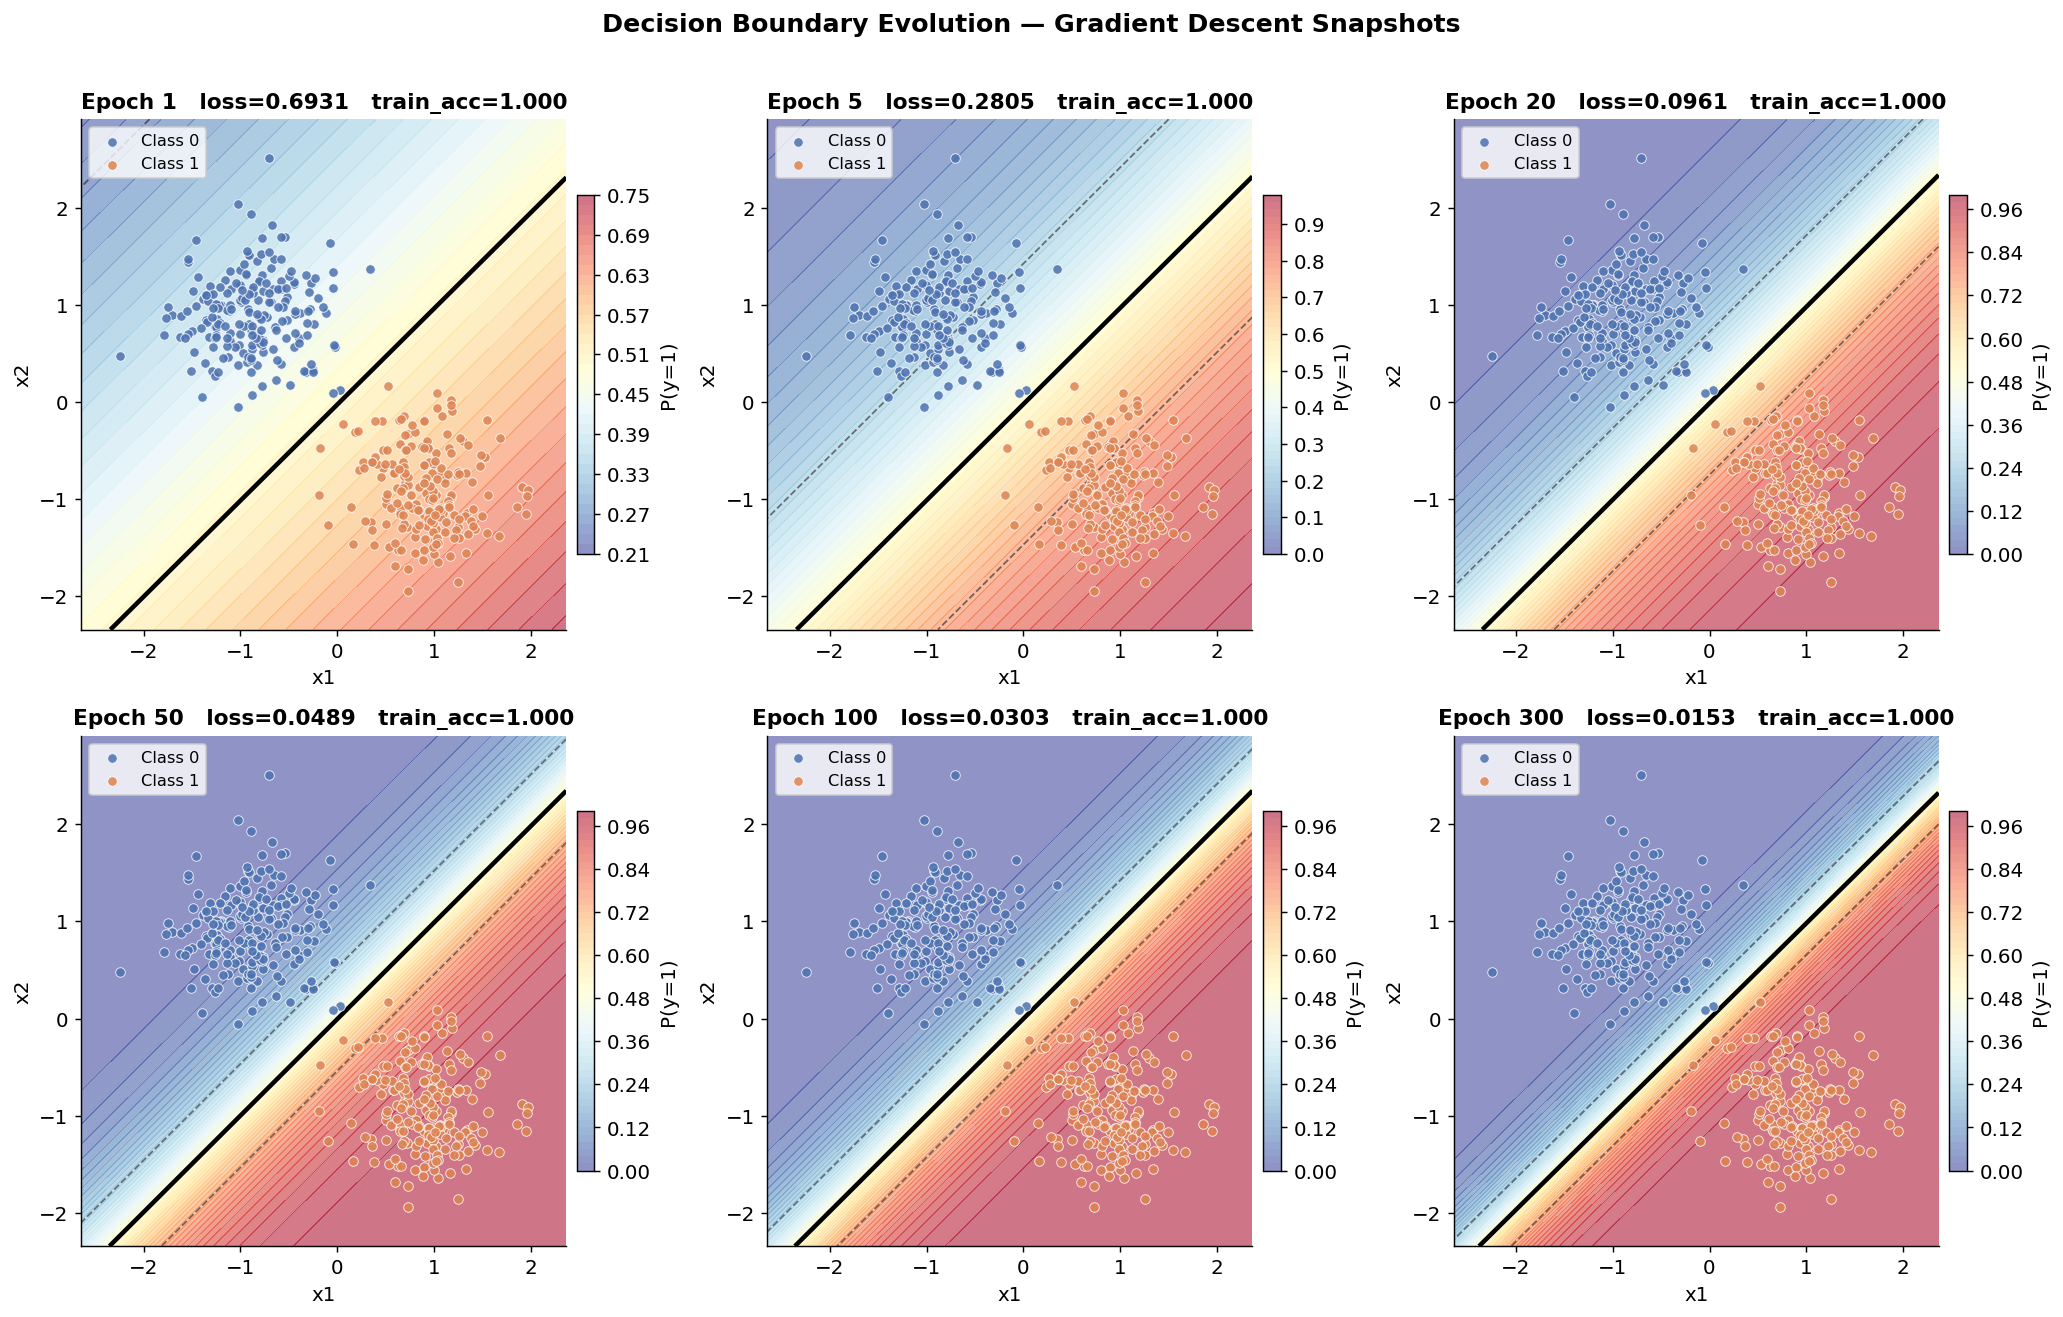

In [9]:
SNAPSHOT_EPOCHS = [1, 5, 20, 50, 100, N_EPOCHS]
snapshots       = []

w_s, b_s = np.zeros(2), 0.0
for epoch in range(1, N_EPOCHS + 1):
    z     = X_train @ w_s + b_s
    y_hat = sigmoid(z)
    dw, db = compute_gradients(X_train, y_train, y_hat, w_s)
    w_s -= LEARNING_RATE * dw
    b_s -= LEARNING_RATE * db
    if epoch in SNAPSHOT_EPOCHS:
        snapshots.append((w_s.copy(), b_s, epoch))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (w_snap, b_snap, ep) in zip(axes.flatten(), snapshots):
    snap_acc  = accuracy(y_train, predict(X_train, w_snap, b_snap))
    snap_loss = history['train_loss'][ep - 1]
    plot_decision_boundary(
        ax, X_train, y_train, w_snap, b_snap,
        title=f'Epoch {ep}   loss={snap_loss:.4f}   train_acc={snap_acc:.3f}',
    )

plt.suptitle('Decision Boundary Evolution — Gradient Descent Snapshots',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 8 · Bonus — L2 Regularisation

Adding `(lambda/2) * ||w||^2` to the loss shrinks weights toward zero.  
The gradient update becomes:
```
dw = (1/N) * X.T @ (y_hat - y) + lambda * w
```
We compare lambdas: 0.0, 0.1, 0.5, 1.0, 5.0, 10.0.

In [10]:
LAMBDAS = [0.0, 0.1, 0.5, 1.0, 5.0, 10.0]
l2_results = []

for lam in LAMBDAS:
    w_l, b_l, hist_l = train_logistic(
        X_train, y_train,
        lr       = LEARNING_RATE,
        n_epochs = N_EPOCHS,
        lam      = lam,
        X_val    = X_test,
        y_val    = y_test,
    )
    l2_results.append({
        'lambda'      : lam,
        '|w|'         : round(float(np.linalg.norm(w_l)), 4),
        'w1'          : round(float(w_l[0]), 4),
        'w2'          : round(float(w_l[1]), 4),
        'b'           : round(float(b_l), 4),
        'train_loss'  : round(float(hist_l['train_loss'][-1]), 5),
        'val_loss'    : round(float(hist_l['val_loss'][-1]),   5),
        'train_acc'   : round(float(accuracy(y_train, predict(X_train, w_l, b_l))), 4),
        'test_acc'    : round(float(accuracy(y_test,  predict(X_test,  w_l, b_l))), 4),
        '_w'          : w_l,
        '_b'          : b_l,
        '_hist'       : hist_l,
    })

l2_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                      for r in l2_results])
print('L2 Regularisation Results:\n')
print(l2_df.to_string(index=False))

L2 Regularisation Results:

 lambda          |w|             w1            w2       b    train_loss      val_loss  train_acc  test_acc
    0.0 4.742200e+00   3.324800e+00 -3.381400e+00 -0.0077  1.531000e-02  6.180000e-03        1.0       1.0
    0.1 1.511200e+00   1.066000e+00 -1.071200e+00 -0.0236  2.732800e-01  2.496400e-01        1.0       1.0
    0.5 6.999000e-01   4.928000e-01 -4.970000e-01 -0.0357  4.748000e-01  4.544000e-01        1.0       1.0
    1.0 4.446000e-01   3.129000e-01 -3.159000e-01 -0.0398  5.522800e-01  5.372300e-01        1.0       1.0
    5.0 2.032051e+52  -1.427519e+52  1.446175e+52 -1.8622 4.588035e+104 1.032308e+105        0.0       0.0
   10.0          inf -2.117965e+179 2.143499e+179 -1.8691           inf           inf        0.0       0.0


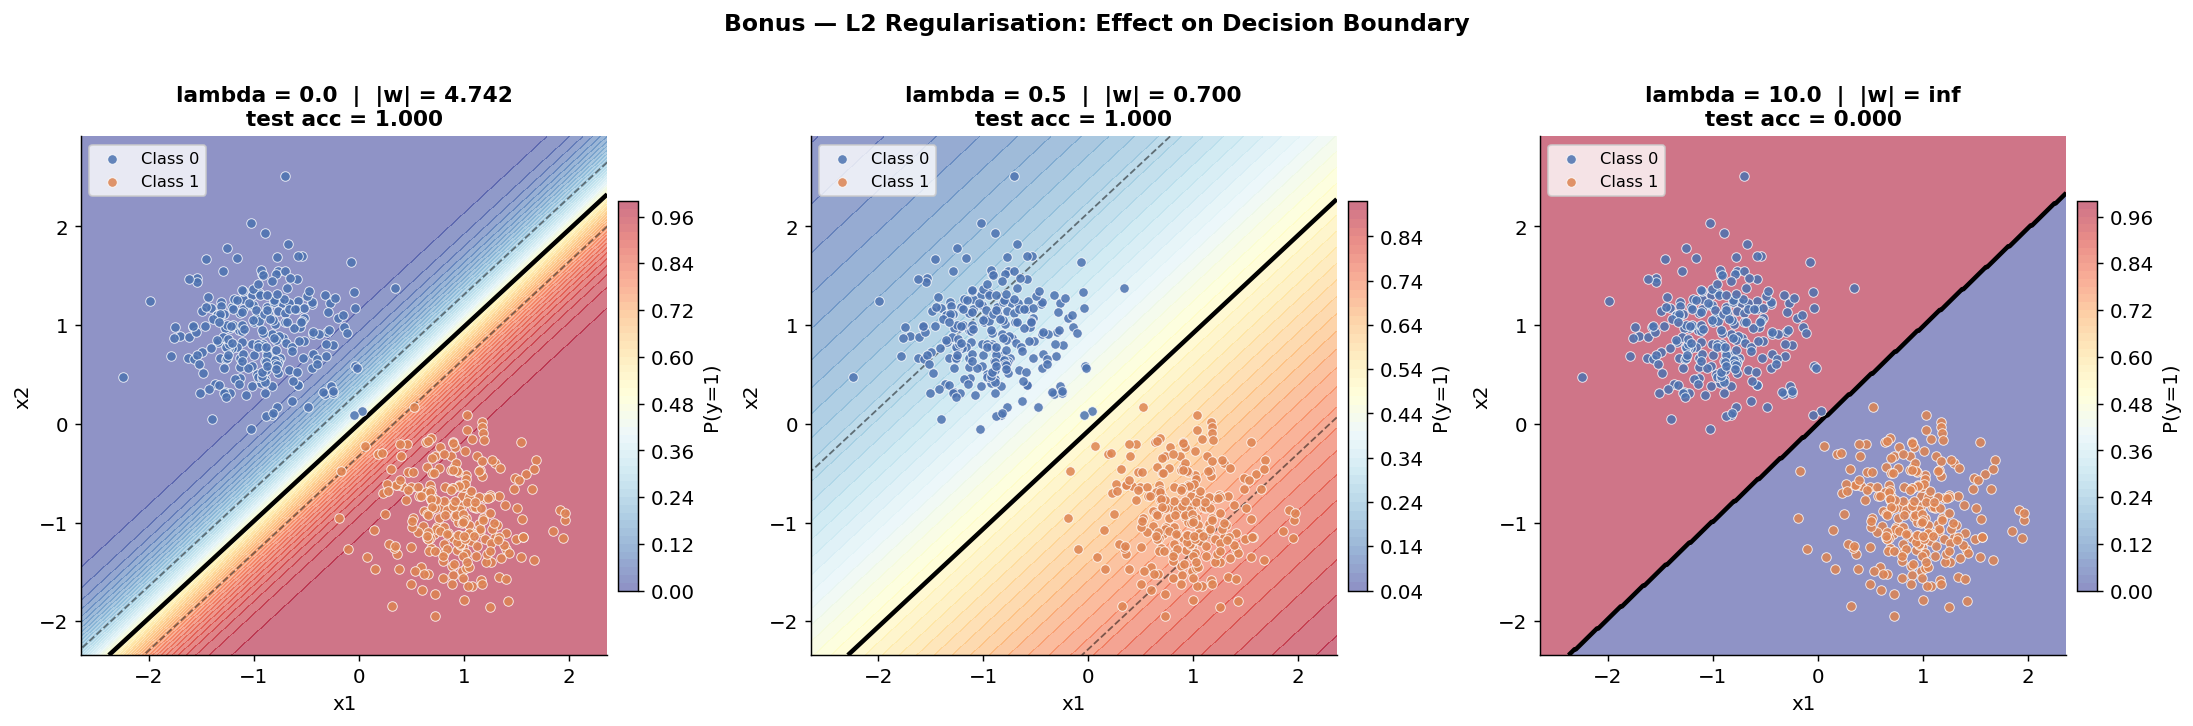

In [11]:
SHOW_LAMBDAS = [0.0, 0.5, 10.0]
show_rows    = [r for r in l2_results if r['lambda'] in SHOW_LAMBDAS]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, row in zip(axes, show_rows):
    plot_decision_boundary(
        ax, X, y, row['_w'], row['_b'],
        title=(
            f'lambda = {row["lambda"]}  |  |w| = {row["|w|"]:.3f}\n'
            f'test acc = {row["test_acc"]:.3f}'
        ),
    )

plt.suptitle('Bonus — L2 Regularisation: Effect on Decision Boundary',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

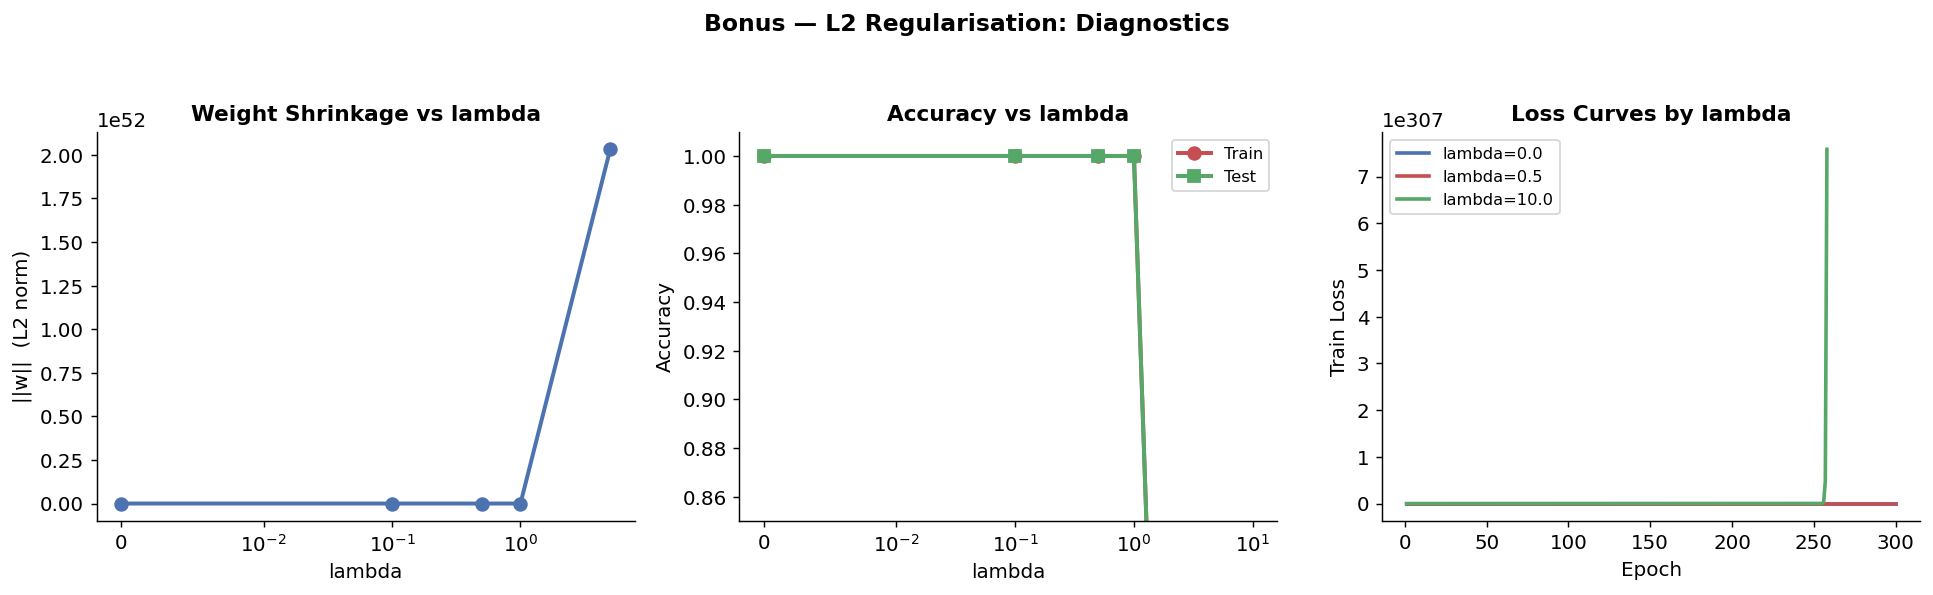

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
lam_vals = l2_df['lambda'].values

axes[0].plot(lam_vals, l2_df['|w|'], 'o-', color=C0, lw=2.2, ms=7)
axes[0].set_xlabel('lambda')
axes[0].set_ylabel('||w||  (L2 norm)')
axes[0].set_title('Weight Shrinkage vs lambda')
axes[0].set_xscale('symlog', linthresh=0.01)

axes[1].plot(lam_vals, l2_df['train_acc'], 'o-', color=C_LOSS, lw=2.2, ms=7, label='Train')
axes[1].plot(lam_vals, l2_df['test_acc'],  's-', color=C_L2,   lw=2.2, ms=7, label='Test')
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs lambda')
axes[1].set_xscale('symlog', linthresh=0.01)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.85, 1.01)

palette = [C0, C_LOSS, C_L2]
for row, col in zip(show_rows, palette):
    axes[2].plot(
        np.arange(1, N_EPOCHS + 1), row['_hist']['train_loss'],
        color=col, lw=2, label=f'lambda={row["lambda"]}',
    )
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Train Loss')
axes[2].set_title('Loss Curves by lambda')
axes[2].legend(fontsize=9)

plt.suptitle('Bonus — L2 Regularisation: Diagnostics',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9 · Interpretation

### Why gradient descent works

At each epoch the algorithm computes the **gradient** of log-loss with respect to every weight — the direction of steepest loss increase — then steps in the opposite direction. For logistic regression the loss surface is **strictly convex**, so there is one global minimum and gradient descent is guaranteed to converge given a small enough learning rate.

The loss curve confirms this: it drops steeply early (large gradient when weights are far from optimal) then flattens as the model approaches convergence. The log-scale view reveals that improvement continues beyond what is visible on the linear scale. The snapshot grid shows the boundary rotating from arbitrary to near-optimal in the first 20 epochs, then making only fine adjustments thereafter.

### The decision boundary is a hyperplane

Logistic regression predicts class 1 when `sigma(w.x + b) >= 0.5`, which is equivalent to `w.x + b = 0` — a straight line in 2D. The probability heatmap shows how confidence varies away from that line: samples near the boundary have predicted probabilities close to 0.5, while those far away approach 0 or 1. The dashed contours at 0.25 and 0.75 mark the 'confidence bands' — the region the model treats as uncertain.

### L2 regularisation: what it does and when to use it

Adding `(lambda/2) * ||w||^2` penalises large weights. The gradient acquires an extra `lambda * w` term that continuously nudges weights back toward zero (sometimes called **weight decay**). Three effects are visible:

1. **Weight norm shrinks** monotonically with lambda — the weight plot confirms the penalty is working.
2. **Boundary stays more central.** A smaller weight vector means a shallower slope in the sigmoid — the boundary is less aggressive toward any particular direction.
3. **Diminishing returns then underfitting.** For well-separated blobs a small lambda barely changes test accuracy; very large lambda forces the boundary toward the origin regardless of the data, causing underfitting.

In sklearn, the `C` parameter of `LogisticRegression` is the inverse of lambda: `C = 1/lambda`. The optimal value is typically found with cross-validation.

## 10 · Final Summary

In [13]:
best_l2_row = l2_df.loc[l2_df['test_acc'].idxmax()]

print('=' * 58)
print('   EXERCISE 8 — FINAL SUMMARY')
print('=' * 58)
print(f'Dataset        : {len(X)} samples, 2 features, 2 classes')
print(f'Learning rate  : {LEARNING_RATE}')
print(f'Epochs         : {N_EPOCHS}')
print()
print(f'No regularisation (lambda=0)')
print(f'  Final train loss : {history["train_loss"][-1]:.5f}')
print(f'  Final val  loss  : {history["val_loss"][-1]:.5f}')
print(f'  Train accuracy   : {accuracy(y_train, predict(X_train, w, b)):.4f}')
print(f'  Test  accuracy   : {accuracy(y_test,  predict(X_test,  w, b)):.4f}')
print(f'  Weights          : w={w.round(4)}, b={b:.4f}')
print()
print(f'Best L2 config (lambda={best_l2_row["lambda"]})')
print(f'  Test accuracy    : {best_l2_row["test_acc"]:.4f}')
print(f'  Weight norm ||w||: {best_l2_row["|w|"]:.4f}')
print('=' * 58)

   EXERCISE 8 — FINAL SUMMARY
Dataset        : 500 samples, 2 features, 2 classes
Learning rate  : 0.5
Epochs         : 300

No regularisation (lambda=0)
  Final train loss : 0.01531
  Final val  loss  : 0.00618
  Train accuracy   : 1.0000
  Test  accuracy   : 1.0000
  Weights          : w=[ 3.3248 -3.3814], b=-0.0077

Best L2 config (lambda=0.0)
  Test accuracy    : 1.0000
  Weight norm ||w||: 4.7422
